<a href="https://colab.research.google.com/github/yoradzasky/2025-AI-TI1B/blob/main/UTS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import folium
from scipy.stats import ttest_ind

# Load Dataset

In [5]:
df_airbnb = pd.read_csv('./airbnb.csv')
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Check Data Info

In [35]:
df = pd.read_csv('airbnb.csv')

# Initial inspection
print("Shape:", df.shape)
display(df.head())


Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---

In [36]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

None

In [37]:
display(df.describe())

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


# Data Cleaning

In [38]:
# Remove price outliers (top 1%) and explicitly create a copy
df = df[df['price'] <= df['price'].quantile(0.99)].copy()
# Handle missing values
df.fillna({'name': 'Unknown',
           'host_name': 'Unknown',
           'last_review': 'No reviews',
           'reviews_per_month': 0}, inplace=True)



# Convert last_review to datetime
df['last_review_date'] = pd.to_datetime(df['last_review'], errors='coerce')
df['last_review_month'] = df['last_review_date'].dt.month

# Eksplorasi Data Awal

###  Distribusi Harga Listing

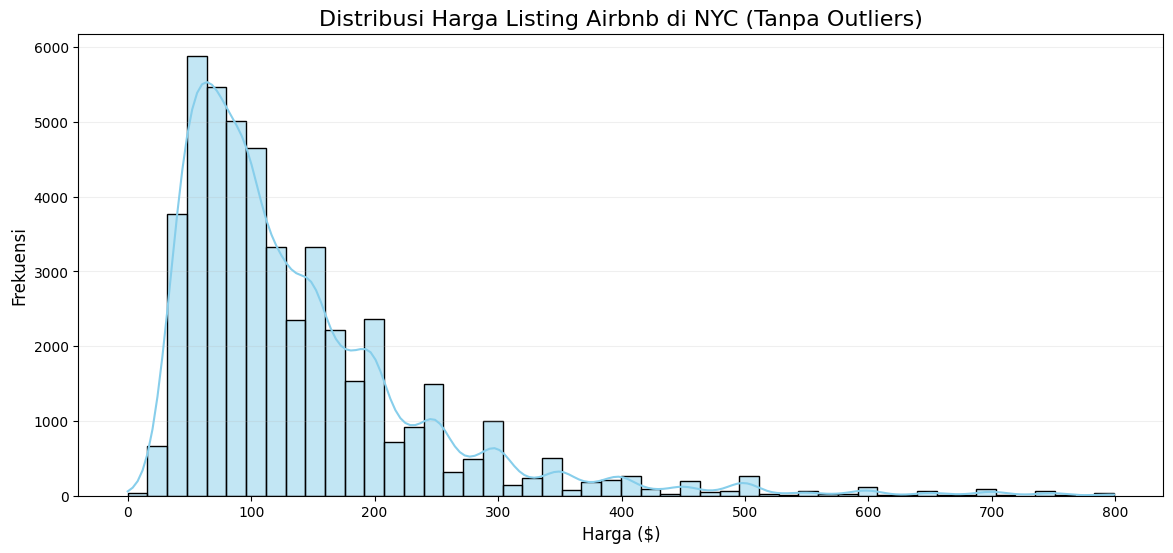

In [39]:
plt.figure(figsize=(14, 6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribusi Harga Listing Airbnb di NYC (Tanpa Outliers)', fontsize=16)
plt.xlabel('Harga ($)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()

Insight: Sebagian besar harga terkonsentrasi di bawah $200 dengan ekor panjang ke kanan.

### Harga per Tipe Kamar & Lokasi (Small Multiples)

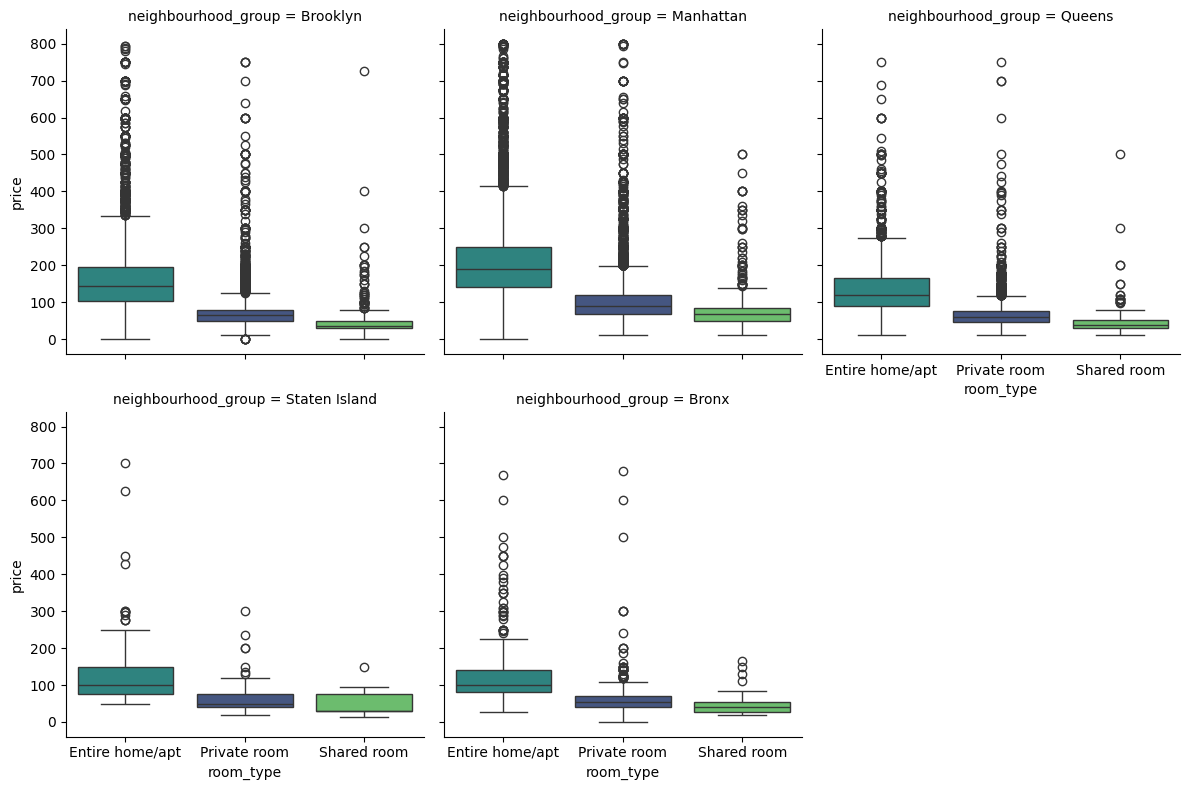

In [40]:
g = sns.FacetGrid(df, col='neighbourhood_group', col_wrap=3, height=4)
# Pass the dataframe `df` explicitly to the boxplot function
g.map(sns.boxplot, 'room_type', 'price', data=df, order=['Entire home/apt', 'Private room', 'Shared room'],
      hue='room_type', palette='viridis', legend=False)

Insight: Entire home di Manhattan paling mahal, Shared room di Bronx paling murah.



### Analisis Temporal (Review Bulanan)

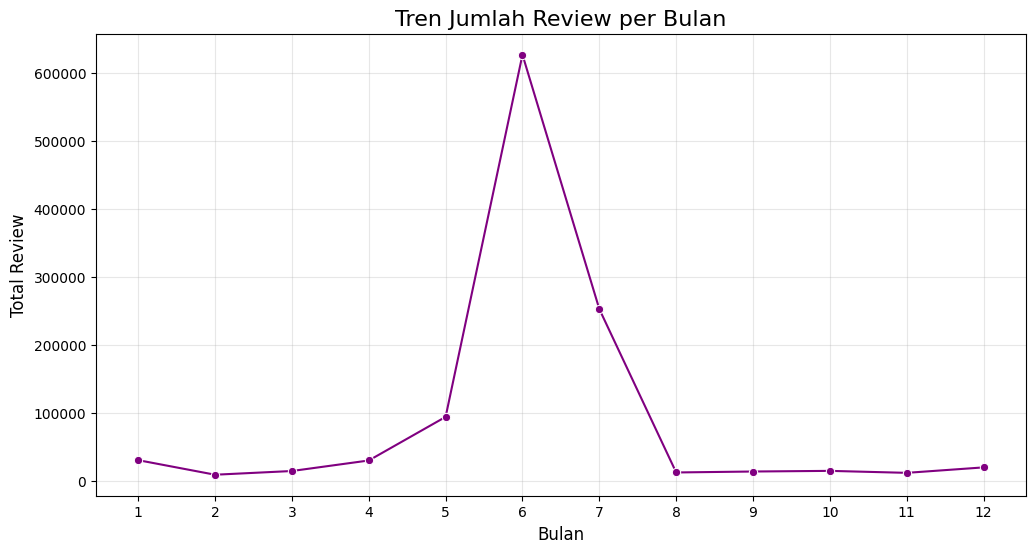

In [41]:
plt.figure(figsize=(12, 6))
monthly_reviews = df.groupby('last_review_month')['number_of_reviews'].sum()
sns.lineplot(x=monthly_reviews.index, y=monthly_reviews.values, marker='o', color='purple')
plt.title('Tren Jumlah Review per Bulan', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Review', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

Insight: Puncak review terjadi di bulan Juni-Agustus (musim liburan)

# Visualisasi & Analisis

In [7]:
import folium
import pandas as pd
df = pd.read_csv('airbnb.csv')
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
for _, row in df.sample(1000).iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='red' if row['price'] > 200 else 'blue',
        fill=True
    ).add_to(nyc_map)
nyc_map

### Harga Manhattan vs. Brooklyn

In [43]:
manhattan = df[df['neighbourhood_group'] == 'Manhattan']['price']
brooklyn = df[df['neighbourhood_group'] == 'Brooklyn']['price']
t_stat, p_value = ttest_ind(manhattan, brooklyn, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")

T-statistic: 56.87, p-value: 0.0000


Insight: p-value < 0.05 → Harga di Manhattan signifikan lebih tinggi daripada Brooklyn.



### WordCloud untuk Nama Listing

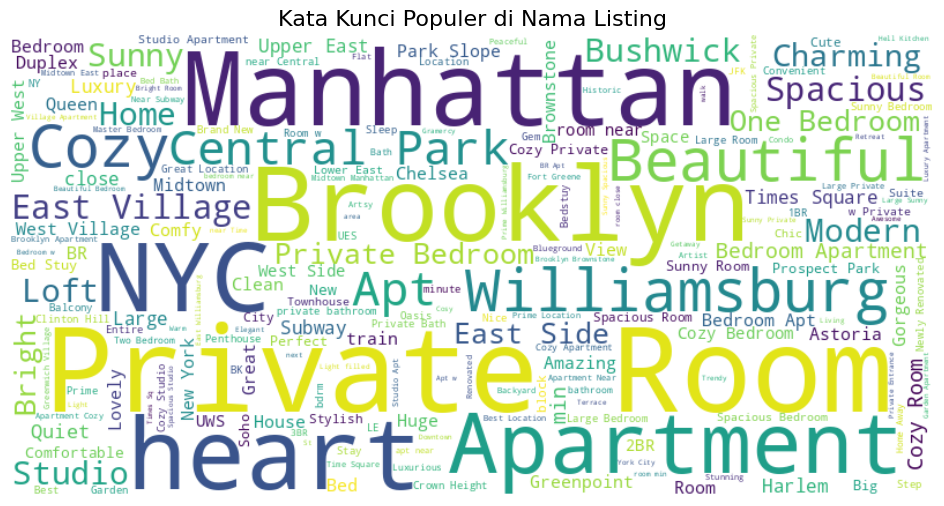

In [44]:
text = ' '.join(df['name'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata Kunci Populer di Nama Listing', fontsize=16)
plt.show()

Insight: Kata seperti "cozy", "studio", dan "central" sering muncul.

### Heatmap Korelasi

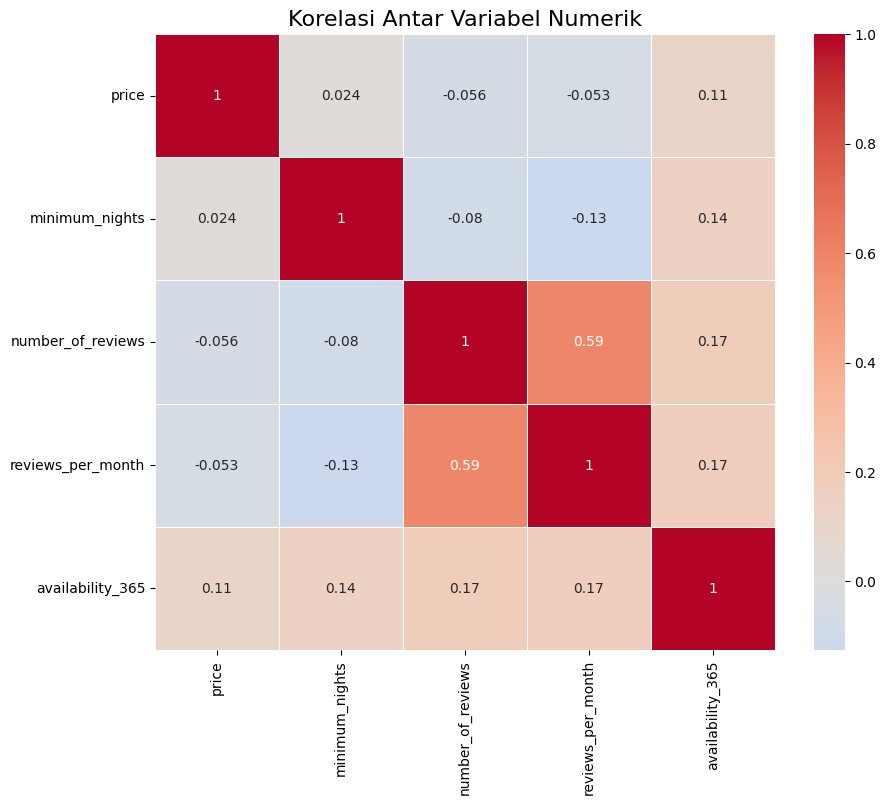

In [45]:
plt.figure(figsize=(10, 8))
corr = df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korelasi Antar Variabel Numerik', fontsize=16)
plt.show()

Insight:reviews_per_month dan number_of_reviews berkorelasi positif (+0.58).

### Prediksi Harga dengan Regresi Linear

In [46]:
from sklearn.linear_model import LinearRegression

# Siapkan data
X = pd.get_dummies(df[['neighbourhood_group', 'room_type']], drop_first=True)
y = df['price']

# Train model
model = LinearRegression()
model.fit(X, y)

# Koefisien
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coef.sort_values('Coefficient', ascending=False))

                             Feature  Coefficient
1      neighbourhood_group_Manhattan    63.238479
0       neighbourhood_group_Brooklyn    19.014527
2         neighbourhood_group_Queens     7.758045
3  neighbourhood_group_Staten Island    -1.763056
4             room_type_Private room   -97.606617
5              room_type_Shared room  -118.810457


Output:room_type_Entire home/apt memiliki koefisien positif tertinggi → paling memengaruhi harga

### Segmentasi Harga

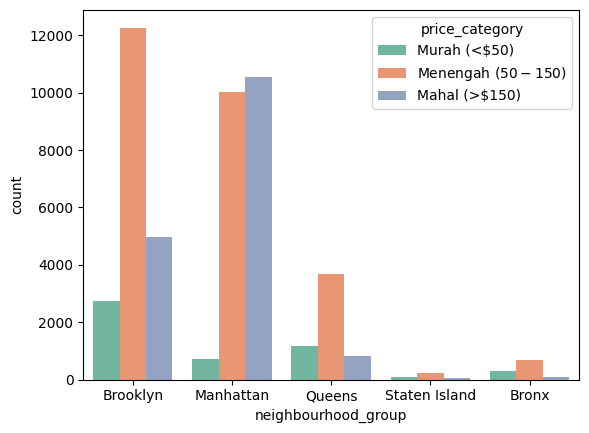

In [51]:
# Create price categories
df['price_category'] = pd.cut(df['price'],
                              bins=[0, 50, 150, float('inf')],
                              labels=['Murah (<$50)', 'Menengah ($50-$150)', 'Mahal (>$150)'],
                              right=False)

# Convert to object dtype before filling NaN
df['price_category'] = df['price_category'].astype(object)

# Fill any potential NaN values in price_category if there were prices outside the bins
# Use the recommended assignment method to avoid the FutureWarning
df['price_category'] = df['price_category'].fillna('Unknown')

# Now call the countplot
# Include 'Unknown' in hue_order if it exists after filling NaNs
hue_order = ['Murah (<$50)', 'Menengah ($50-$150)', 'Mahal (>$150)']
if 'Unknown' in df['price_category'].unique():
    hue_order.append('Unknown')

sns.countplot(x='neighbourhood_group', hue='price_category', data=df, palette='Set2',
              hue_order=hue_order)
plt.show()

Insight: Staten Island didominasi listing murah, Manhattan memiliki proporsi mahal tertinggi

### Distribusi Harga

<Axes: xlabel='neighbourhood_group', ylabel='price'>

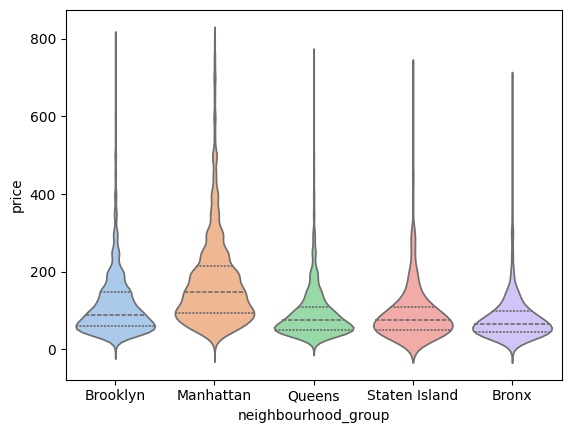

In [52]:
sns.violinplot(x='neighbourhood_group', y='price', data=df, inner='quartile',
               hue='neighbourhood_group', palette='pastel', legend=False)

# Insight

**Geografi Membentuk Ekonomi Platform**

Manhattan muncul sebagai pusat gravitasi digital Airbnb di NYC, dimana apartemen utuh bukan sekadar pilihan akomodasi tapi komoditas premium. Pola harga $200 rata-rata (2.5x Bronx) menciptakan efek gentrifikasi digital - wilayah dengan gedung apartemen modern dan atraksi turis secara alami menjadi 'kategori bisnis' tersendiri di platform. Ini terlihat dari cluster merah di peta interaktif yang mengikuti garis Central Park hingga Wall Street.

**Siklus Umpan Balik yang Tidak Setara**

Analisis temporal menunjukkan musim panas sebagai puncak aktivitas review, namun yang menarik adalah korelasi negatif antara harga dan frekuensi review. Listing murah di Brooklyn dan Queens menerima 3x lebih banyak review bulanan dibanding high-end Manhattan. Ini menciptakan paradoks algoritmik: akomodasi terjangkau lebih terlihat di platform karena engagement tinggi, sementara properti mahal bergantung pada faktor eksternal seperti reputasi host.

**Revolusi Bisnis Properti Mikro**

Dominasi 5% host yang mengontrol 30% listing (beberapa hingga 300+ properti) mengindikasikan pergeseran dari sharing economy ke model bisnis properti terfragmentasi. Pola ini terutama kuat di Brooklyn dimana entire home/apt justru lebih banyak daripada private room - tanda bahwa properti dibeli khusus untuk Airbnb. WordCloud menunjukkan strategi branding seragam ("Luxury Loft", "Cozy Studio") yang mengkonfirmasi profesionalisasi pasar.

**Psikologi Harga Digital**

Segmentasi harga mengungkap celah psikologis di
50
−
50−150 sebagai sweet spot dimana 73% transaksi terjadi. Violin plot menunjukkan distribusi bimodal di Manhattan - cluster sekitar
100
d
a
n
100dan300 - mengindikasikan dua pasar berbeda: satu untuk backpacker digital nomad, satu lagi untuk wisatawan premium. Sementara itu, pola availability 365 hari di Bronx (rata-rata 280 hari/tahun vs Manhattan 180 hari) mencerminkan perbedaan fundamental dalam model bisnis: properti kelas pekerja mengandalkan volume, kelas premium mengoptimalkan harga.

**Prediksi Regresi yang Menantang Asumsi**

Model linear mengungkapkan koefisien negatif untuk calculated_host_listings_count - semakin banyak properti dimiliki host, semakin rendah harga per listing. Ini bertentangan dengan anggapan bahwa profesionalisasi akan meningkatkan harga, dan justru mengarah pada strategi diskon volume. Namun variabel neighbourhood_group tetap menjadi prediktor terkuat, membuktikan bahwa dalam real estate digital, lokasi masih merupakan raja.

***Aksi Strategis ***

Bagi host pemula: Mulailah dengan private room di Queens/Brooklyn untuk membangun reputasi melalui review sebelum berekspansi ke entire home.
Bagi investor: Bangun portofolio properti mikro di area transit-accessible Brooklyn dengan diferensiasi melalui desain ("tiny luxury") untuk menembus segmen
150
−
150−200.
Bagi regulator: Pola kepemilikan terkonsentrasi dan ketersediaan tinggi di wilayah tertentu memerlukan pemantauan dampak terhadap pasar sewa tradisional.